In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

c:\Users\User\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset = load_dataset("lukebarousse/data_jobs")

In [60]:
df = dataset['train'].to_pandas()

In [61]:
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [78]:
df_country = df[df['job_country'] == 'Belgium'].copy()

In [63]:
df_country['job_month'] = df_country['job_posted_date'].dt.strftime('%B')

In [64]:
df_country_jobs = df_country.pivot_table(
    index = 'job_month',
    columns = 'job_title_short',
    aggfunc = 'size'
)
df_country_jobs

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_month,,,,,,,,,,
April,103,20,360,318,163,11,26,32,22,77
August,93,20,354,245,157,26,6,32,21,53
December,93,15,211,185,134,11,17,17,15,63
February,67,15,263,247,123,16,12,20,16,28
January,128,24,451,481,288,21,32,48,47,72
July,82,16,310,252,167,20,19,36,27,60
June,52,6,322,299,178,12,12,21,24,20
March,90,14,333,359,186,24,13,30,27,37
May,51,3,297,244,131,21,19,15,23,29


In [65]:
df_country_jobs.reset_index(inplace=True)
df_country_jobs

job_title_short,job_month,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
0,April,103,20,360,318,163,11,26,32,22,77
1,August,93,20,354,245,157,26,6,32,21,53
2,December,93,15,211,185,134,11,17,17,15,63
3,February,67,15,263,247,123,16,12,20,16,28
4,January,128,24,451,481,288,21,32,48,47,72
5,July,82,16,310,252,167,20,19,36,27,60
6,June,52,6,322,299,178,12,12,21,24,20
7,March,90,14,333,359,186,24,13,30,27,37
8,May,51,3,297,244,131,21,19,15,23,29
9,November,110,33,292,193,143,17,18,24,25,63


In [66]:
df_country_jobs['month_number'] = pd.to_datetime(df_country_jobs['job_month'], format='%B').dt.month

In [67]:
df_country_jobs.sort_values('month_number', inplace=True)

In [ ]:
df_country_jobs.set_index('job_month', inplace=True)

In [70]:
df_country_jobs.drop(columns='month_number', inplace=True)

In [85]:
jobs = df_country['job_title_short'].value_counts().head(3)
jobs = jobs.index.tolist()

In [88]:
df_country_jobs

job_title_short,Data Analyst,Data Engineer,Data Scientist
job_month,,,
January,451,481,288
February,263,247,123
March,333,359,186
April,360,318,163
May,297,244,131
June,322,299,178
July,310,252,167
August,354,245,157
September,272,215,163


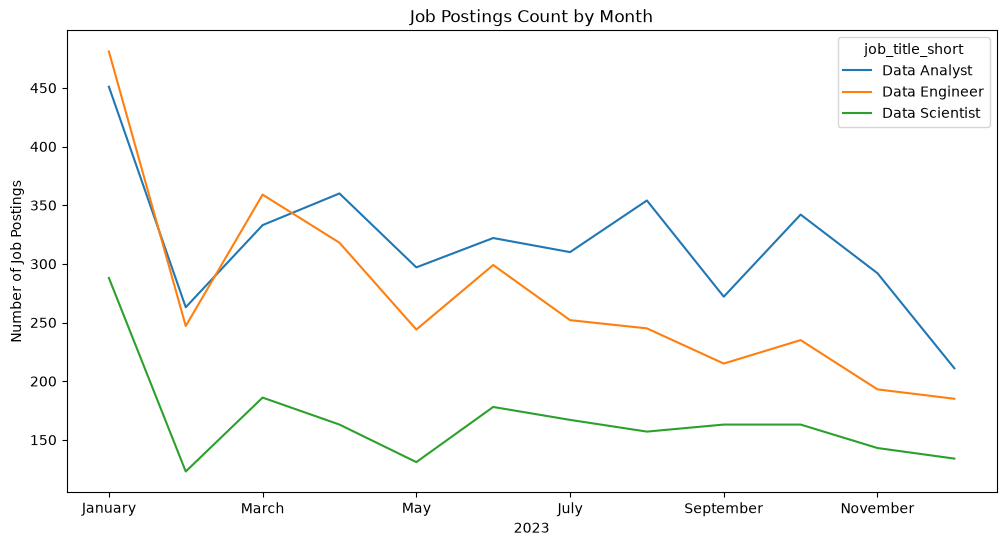

In [87]:
df_country_jobs[jobs].plot(kind='line', figsize=(12, 6))
plt.title('Job Postings Count by Month')
plt.xlabel('2023')
plt.ylabel('Number of Job Postings')
plt.show()